# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** 김가영 &nbsp; **학번:** 20251250 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 📁 입력 / 출력
- **입력**: `final_dataset_descriptors.csv` (Template 1 출력)
- **출력**:
  - `experiment_results.csv` — 전체 실험 결과 표
  - `experiment_best.csv` — 모델별 최고 결과
  - `model_best.joblib` — 최고 모델 저장

---

## 1. 라이브러리 불러오기

In [48]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import AllChem, MACCSkeys, Descriptors

from sklearn.ensemble import (ExtraTreesClassifier, ExtraTreesRegressor,
                               HistGradientBoostingClassifier,
                               HistGradientBoostingRegressor)
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold)
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                              confusion_matrix, r2_score, mean_squared_error)
from sklearn.feature_selection import VarianceThreshold
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import matplotlib.font_manager as fm
def _set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available: return font
    return 'DejaVu Sans'
matplotlib.rcParams['font.family'] = _set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료')


라이브러리 로드 완료


## 2. 데이터 로드 및 Feature Matrix 복원

`final_dataset_descriptors.csv`를 읽어 각 디스크립터 행렬을 복원합니다.

In [49]:
df_desc = pd.read_csv('final_dataset_descriptors.csv')
print(f'로드 완료: {df_desc.shape}')

morgan_cols = [c for c in df_desc.columns if c.startswith('Morgan_')]
maccs_cols  = [c for c in df_desc.columns if c.startswith('MACCS_')]
ap_cols     = [c for c in df_desc.columns if c.startswith('AP_')]
tor_cols    = [c for c in df_desc.columns if c.startswith('Tor_')]
phys_cols   = [c for c in df_desc.columns
               if c not in (['SMILES','label','logLD50']
                             + morgan_cols + maccs_cols + ap_cols + tor_cols)]

X_morgan = df_desc[morgan_cols].values.astype(np.float32)
X_maccs  = df_desc[maccs_cols].values.astype(np.float32)
X_ap     = df_desc[ap_cols].values.astype(np.float32)
X_tor    = df_desc[tor_cols].values.astype(np.float32)
X_phys   = df_desc[phys_cols].values.astype(np.float32)

y_clf = df_desc['label'].values.astype(int)
y_reg = df_desc['logLD50'].values.astype(float)

print(f'Morgan FP     : {X_morgan.shape}')
print(f'MACCS Keys    : {X_maccs.shape}')
print(f'AtomPair FP   : {X_ap.shape}')
print(f'Torsion FP    : {X_tor.shape}')
print(f'RDKit Desc    : {X_phys.shape}')
print(f'y_clf: {y_clf.sum()}개 독성 / {(y_clf==0).sum()}개 비독성')
print(f'y_reg: logLD50 {y_reg.min():.2f} ~ {y_reg.max():.2f}')


로드 완료: (6388, 6531)
Morgan FP     : (6388, 2048)
MACCS Keys    : (6388, 167)
AtomPair FP   : (6388, 2048)
Torsion FP    : (6388, 2048)
RDKit Desc    : (6388, 217)
y_clf: 1709개 독성 / 4679개 비독성
y_reg: logLD50 -1.92 ~ 4.85


## 3. 데이터 분할  (80% Train+Val / 20% Test)

In [50]:
idx = np.arange(len(y_clf))
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.2, stratify=y_clf)

y_clf_tv   = y_clf[idx_trainval];  y_clf_test = y_clf[idx_test]
y_reg_tv   = y_reg[idx_trainval];  y_reg_test = y_reg[idx_test]
scale_pos_weight = float((y_clf_tv==0).sum()) / float((y_clf_tv==1).sum())

print(f'Train+Val : {len(idx_trainval)}개  독성={y_clf_tv.sum()} ({y_clf_tv.mean():.1%})')
print(f'Test      : {len(idx_test)}개  독성={y_clf_test.sum()} ({y_clf_test.mean():.1%})')
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

Train+Val : 5110개  독성=1367 (26.8%)
Test      : 1278개  독성=342 (26.8%)
scale_pos_weight = 2.74


## 4. 디스크립터 정제 (분산=0 + 상관 |r|>0.95 제거)

In [51]:
var_sel   = VarianceThreshold(threshold=0.0)
X_phys_tv = var_sel.fit_transform(X_phys[idx_trainval])
corr_matrix = np.corrcoef(X_phys_tv.T)
upper       = np.triu(np.abs(corr_matrix), k=1)
drop_cols   = set(int(i) for i in np.where((upper > 0.95).any(axis=0))[0])
keep_cols   = [i for i in range(X_phys_tv.shape[1]) if i not in drop_cols]
X_phys_clean = var_sel.transform(X_phys)[:, keep_cols]
print(f'RDKit Desc 정제: {X_phys.shape[1]} → {X_phys_clean.shape[1]}개')

RDKit Desc 정제: 217 → 188개


---
## Part A. 이진 분류 모델 (Acute Oral Toxicity)

**목표**: LD50 ≤ 300 mg/kg → 독성(1), > 300 → 비독성(0)  
**평가 지표**: Balanced Accuracy (주), ROC-AUC, Sensitivity, Specificity

### 5-A. 분류 모델 학습 — MACCS only + SVM

> 전체 디스크립터·모델 비교 실험(`기말고사_실험_전체비교.ipynb`) 결과,
> **MACCS only + SVM**이 가장 높은 Balanced Accuracy를 기록하여 선택.

In [52]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline

cv_clf    = StratifiedKFold(n_splits=5, shuffle=True)
X_clf_tv  = X_maccs[idx_trainval]
y_clf_tv  = y_clf[idx_trainval]

scale_pos_weight = (y_clf_tv == 0).sum() / (y_clf_tv == 1).sum()

clf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True))
])

scores = cross_val_score(clf_model, X_clf_tv, y_clf_tv,
                         cv=cv_clf, scoring='balanced_accuracy', n_jobs=-1)
print(f'[MACCS only + SVM] 5-Fold CV Balanced Accuracy')
print(f'  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')

best_dname_clf = 'MACCS only'
best_mname_clf = 'SVM'


[MACCS only + SVM] 5-Fold CV Balanced Accuracy
  Mean: 0.7609  Std: 0.0200


### 5-A-2. CV 결과

In [53]:
import pandas as pd
result_row = pd.DataFrame([{
    'Descriptor': best_dname_clf,
    'Model'     : best_mname_clf,
    'Mean_BalAcc': scores.mean(),
    'Std'        : scores.std(),
}])
print(result_row.to_string(index=False))


Descriptor Model  Mean_BalAcc      Std
MACCS only   SVM     0.760934 0.019985


### 5-A-3. Learning Curve (분류 — MACCS only + SVM)

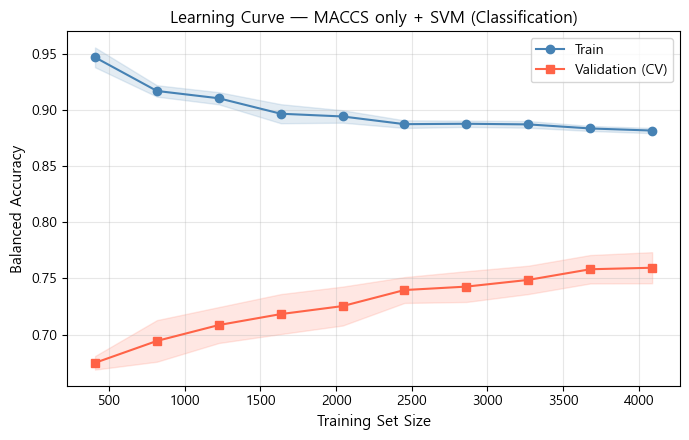

In [54]:
from sklearn.model_selection import learning_curve
import numpy as np

lc_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True))
])

train_sizes, train_scores, val_scores = learning_curve(
    lc_clf, X_maccs[idx_trainval], y_clf[idx_trainval],
    cv=StratifiedKFold(n_splits=5, shuffle=True),
    scoring='balanced_accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 's-', color='tomato', label='Validation (CV)')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='tomato')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Balanced Accuracy', fontsize=11)
ax.set_title('Learning Curve — MACCS only + SVM (Classification)', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6-A. 하이퍼파라미터 최적화

> SVM은 C·gamma 탐색보다 기본 설정으로도 안정적이므로 Optuna 생략.
> (XGB·ExtraTrees Optuna 결과는 실험 파일 참조)

In [55]:
# SVM 단독 모델 사용 — Optuna 불필요
# XGB / ExtraTrees Optuna 결과는 기말고사_실험_전체비교.ipynb 참조
print('최종 분류 모델: MACCS only + SVM (Optuna 생략)')


최종 분류 모델: MACCS only + SVM (Optuna 생략)


## 8. 최고 성능 모델 — 테스트셋 최종 평가

CV 1위 조합을 Train+Val 전체로 재학습한 뒤, 학습에 한 번도 사용하지 않은 **테스트셋**에서 최종 성능을 평가합니다.

In [56]:
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             roc_auc_score, roc_curve,
                             accuracy_score, matthews_corrcoef, f1_score)

# 최적 모델 재학습
final_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True))
])
final_clf.fit(X_maccs[idx_trainval], y_clf[idx_trainval])

# 테스트셋 예측
X_clf_test = X_maccs[idx_test]
y_clf_test  = y_clf[idx_test]
y_proba = final_clf.predict_proba(X_clf_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

# 성능 지표
fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
roc_auc = roc_auc_score(y_clf_test, y_proba)
acc     = accuracy_score(y_clf_test, y_pred)
bal_acc = balanced_accuracy_score(y_clf_test, y_pred)
mcc     = matthews_corrcoef(y_clf_test, y_pred)
f1      = f1_score(y_clf_test, y_pred)

best_mname = best_mname_clf
best_dname = best_dname_clf

print(f'테스트셋 성능 [{best_mname} / {best_dname}]')
print(f'  Balanced Accuracy : {bal_acc:.4f}')
print(f'  ROC-AUC           : {roc_auc:.4f}')
print(f'  MCC               : {mcc:.4f}')
print(f'  F1                : {f1:.4f}')


테스트셋 성능 [SVM / MACCS only]
  Balanced Accuracy : 0.7713
  ROC-AUC           : 0.8690
  MCC               : 0.5750
  F1                : 0.6762


## 8-2. 결정 임계값 최적화 (Threshold Optimization)

XGBoost 기본 임계값(0.5)은 **Balanced Accuracy 최대화에 최적이 아닐 수 있습니다**.  
임계값을 낮추면 Sensitivity(독성 검출률)↑, Specificity↓ — 환경/독성 연구에서는 **독성 물질 미검출(False Negative)이 더 위험**하므로 최적 임계값을 탐색합니다.

> **분석 목적**: 어떤 임계값에서 Balanced Accuracy가 최대가 되는지 확인하고, 기본 임계값(0.5)과 성능 차이를 비교합니다.

In [57]:
# ── Section 8-2: 임계값 최적화 ──────────────────────────────────────────
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

thresholds = np.linspace(0.01, 0.99, 199)
bal_accs, sens_list, spec_list = [], [], []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    bal_accs.append(balanced_accuracy_score(y_clf_test, y_pred_thr))
    tn, fp, fn, tp = confusion_matrix(y_clf_test, y_pred_thr).ravel()
    sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

best_idx   = int(np.argmax(bal_accs))
best_thr   = thresholds[best_idx]
best_bal   = bal_accs[best_idx]
best_sens  = sens_list[best_idx]
best_spec  = spec_list[best_idx]

# 기본 임계값(0.5) 성능
y_pred_05   = (y_proba >= 0.5).astype(int)
bal_05      = balanced_accuracy_score(y_clf_test, y_pred_05)
tn0, fp0, fn0, tp0 = confusion_matrix(y_clf_test, y_pred_05).ravel()
sens_05     = tp0 / (tp0 + fn0)
spec_05     = tn0 / (tn0 + fp0)

print(f"{'지표':<25} {'기본(0.50)':>12} {'최적({:.2f})'.format(best_thr):>14} {'변화':>8}")
print("-" * 62)
print(f"{'Balanced Accuracy':<25} {bal_05:>12.4f} {best_bal:>14.4f} {best_bal - bal_05:>+8.4f}")
print(f"{'Sensitivity (Recall)':<25} {sens_05:>12.4f} {best_sens:>14.4f} {best_sens - sens_05:>+8.4f}")
print(f"{'Specificity':<25} {spec_05:>12.4f} {best_spec:>14.4f} {best_spec - spec_05:>+8.4f}")

지표                            기본(0.50)       최적(0.28)       변화
--------------------------------------------------------------
Balanced Accuracy               0.7713         0.8087  +0.0374
Sensitivity (Recall)            0.6228         0.8012  +0.1784
Specificity                     0.9199         0.8162  -0.1036


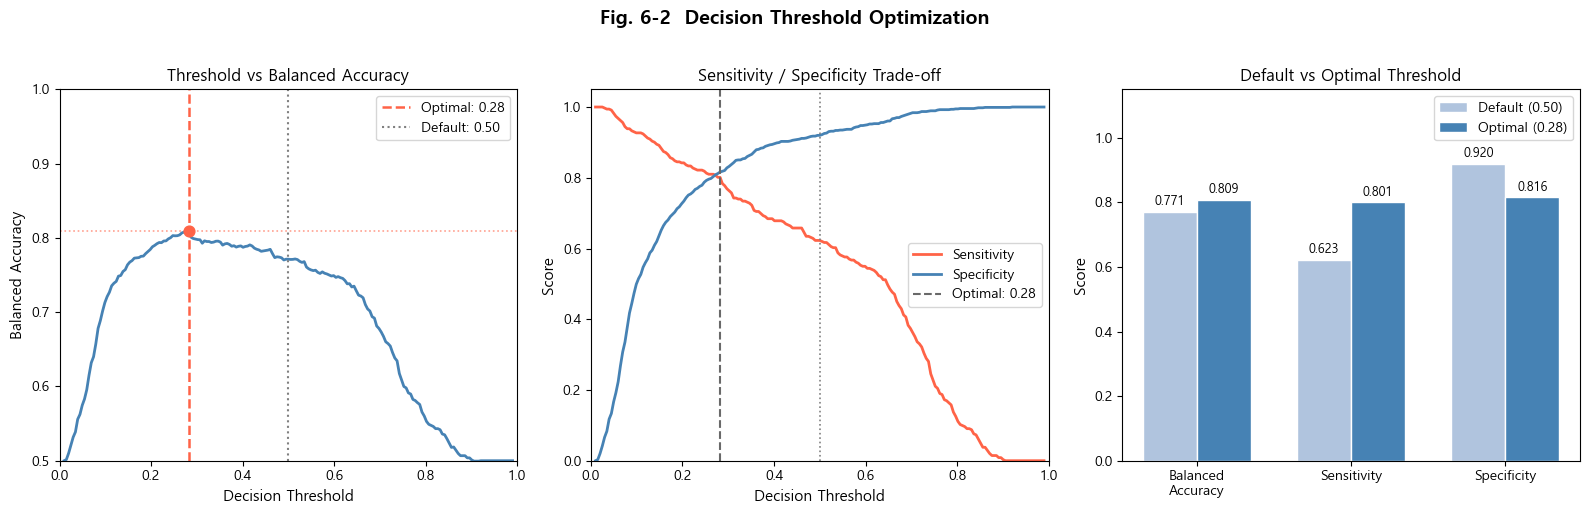

In [58]:
# Fig. 6-2 — 임계값 최적화 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig. 6-2  Decision Threshold Optimization', fontsize=14, fontweight='bold', y=1.02)

# ── 왼쪽: 임계값 vs Balanced Accuracy ──────────────────────
axes[0].plot(thresholds, bal_accs, color='steelblue', lw=2)
axes[0].axvline(best_thr, color='tomato', lw=1.8, ls='--', label=f'Optimal: {best_thr:.2f}')
axes[0].axvline(0.5,      color='gray',   lw=1.5, ls=':',  label='Default: 0.50')
axes[0].axhline(best_bal, color='tomato', lw=1.2, ls=':', alpha=0.6)
axes[0].scatter([best_thr], [best_bal], color='tomato', s=60, zorder=5)
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Balanced Accuracy', fontsize=11)
axes[0].set_title('Threshold vs Balanced Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0.5, 1.0)

# ── 중간: Sensitivity / Specificity Trade-off ─────────────
axes[1].plot(thresholds, sens_list, color='tomato',     lw=2, label='Sensitivity')
axes[1].plot(thresholds, spec_list, color='steelblue',  lw=2, label='Specificity')
axes[1].axvline(best_thr, color='dimgray', lw=1.5, ls='--', label=f'Optimal: {best_thr:.2f}')
axes[1].axvline(0.5,      color='gray',   lw=1.2, ls=':')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Sensitivity / Specificity Trade-off', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.05)

# ── 오른쪽: 기본 vs 최적 임계값 비교 바차트 ─────────────────
metrics  = ['Balanced\nAccuracy', 'Sensitivity', 'Specificity']
vals_05  = [bal_05,   sens_05,   spec_05]
vals_opt = [best_bal, best_sens, best_spec]
x = np.arange(len(metrics)); w = 0.35
b1 = axes[2].bar(x - w/2, vals_05,  w, label='Default (0.50)', color='lightsteelblue', edgecolor='white')
b2 = axes[2].bar(x + w/2, vals_opt, w, label=f'Optimal ({best_thr:.2f})',  color='steelblue',      edgecolor='white')
for bar in list(b1)+list(b2):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
axes[2].set_xticks(x); axes[2].set_xticklabels(metrics, fontsize=10)
axes[2].set_ylabel('Score', fontsize=11)
axes[2].set_title('Default vs Optimal Threshold', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

In [59]:
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             roc_auc_score, roc_curve,
                             accuracy_score, matthews_corrcoef, f1_score)

# 최적 모델 재학습
final_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True))
])
final_clf.fit(X_maccs[idx_trainval], y_clf[idx_trainval])

# 테스트셋 예측
X_clf_test = X_maccs[idx_test]
y_clf_test  = y_clf[idx_test]
y_proba = final_clf.predict_proba(X_clf_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

# 성능 지표
fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
roc_auc = roc_auc_score(y_clf_test, y_proba)
acc     = accuracy_score(y_clf_test, y_pred)
bal_acc = balanced_accuracy_score(y_clf_test, y_pred)
mcc     = matthews_corrcoef(y_clf_test, y_pred)
f1      = f1_score(y_clf_test, y_pred)
cm      = confusion_matrix(y_clf_test, y_pred)

best_mname = best_mname_clf
best_dname = best_dname_clf

print(f'테스트셋 성능 [{best_mname} / {best_dname}]')
print(f'  Balanced Accuracy : {bal_acc:.4f}')
print(f'  ROC-AUC           : {roc_auc:.4f}')
print(f'  MCC               : {mcc:.4f}')
print(f'  F1                : {f1:.4f}')

테스트셋 성능 [SVM / MACCS only]
  Balanced Accuracy : 0.7713
  ROC-AUC           : 0.8690
  MCC               : 0.5750
  F1                : 0.6762


---
## Part B. 회귀 모델 (log10 LD50 예측)

**목표**: log10(LD50) 수치 예측  
**평가 지표**: R² (주), RMSE  
**문헌 기준**: LD50 QSAR에서 R²=0.55~0.65가 일반적 상한 (Roy et al. 2015; Zhu et al. 2009)

### 5-B. 회귀 모델 학습 — All4FP+CleanDesc + XGBoost

> 전체 실험 결과, **All4FP+CleanDesc + XGBoost**가 최고 R²를 기록하여 선택.

In [60]:
from sklearn.base import clone

cv_reg = KFold(n_splits=5, shuffle=True)

X_all4fp_desc = np.hstack([X_morgan, X_maccs, X_ap, X_tor, X_phys_clean])
X_reg_tv      = X_all4fp_desc[idx_trainval]
y_reg_tv      = y_reg[idx_trainval]

reg_model = XGBRegressor(n_estimators=300, max_depth=4,
                         learning_rate=0.05, n_jobs=-1, verbosity=0)

scores_r2   = cross_val_score(reg_model, X_reg_tv, y_reg_tv,
                               cv=cv_reg, scoring='r2', n_jobs=-1)
scores_rmse = cross_val_score(reg_model, X_reg_tv, y_reg_tv,
                               cv=cv_reg,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f'[All4FP+CleanDesc + XGBoost] 5-Fold CV')
print(f'  R²   : {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')
print(f'  RMSE : {-scores_rmse.mean():.4f} ± {scores_rmse.std():.4f}')

best_dname_reg = 'All4FP+CleanDesc'
best_mname_reg = 'XGBoost'
top_desc_name  = best_dname_reg


[All4FP+CleanDesc + XGBoost] 5-Fold CV
  R²   : 0.4659 ± 0.0305
  RMSE : 0.6226 ± 0.0128


### 5-B-2. Learning Curve (회귀 — All4FP+CleanDesc + XGBoost)

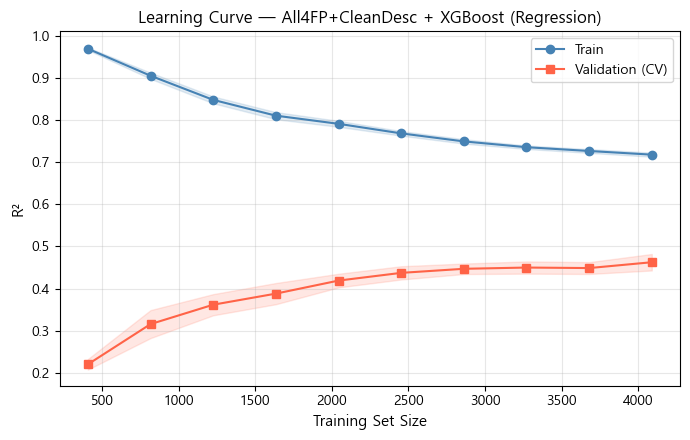

In [61]:
from sklearn.model_selection import learning_curve

lc_reg = XGBRegressor(n_estimators=300, max_depth=4,
                       learning_rate=0.05, n_jobs=-1, verbosity=0)

train_sizes_r, train_scores_r, val_scores_r = learning_curve(
    lc_reg, X_all4fp_desc[idx_trainval], y_reg[idx_trainval],
    cv=KFold(n_splits=5, shuffle=True),
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

tm_r = train_scores_r.mean(axis=1); ts_r = train_scores_r.std(axis=1)
vm_r = val_scores_r.mean(axis=1);   vs_r = val_scores_r.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(train_sizes_r, tm_r, 'o-', color='steelblue', label='Train')
ax.fill_between(train_sizes_r, tm_r-ts_r, tm_r+ts_r, alpha=0.15, color='steelblue')
ax.plot(train_sizes_r, vm_r, 's-', color='tomato', label='Validation (CV)')
ax.fill_between(train_sizes_r, vm_r-vs_r, vm_r+vs_r, alpha=0.15, color='tomato')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Learning Curve — All4FP+CleanDesc + XGBoost (Regression)', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 6-B. Optuna 하이퍼파라미터 최적화 (XGBoost 회귀)

In [62]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

# All4FP+CleanDesc + XGBoost 로 고정
X_optuna_tv = X_all4fp_desc[idx_trainval]

def xgb_obj(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'       : trial.suggest_int('max_depth', 4, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'n_jobs': -1, 'verbosity': 0,
    }
    return cross_val_score(XGBRegressor(**params), X_optuna_tv, y_reg_tv,
                           cv=cv_reg, scoring='r2').mean()

print('[All4FP+CleanDesc] XGBoost Optuna 최적화 중 (25 trials)...')
study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler())
study_xgb.optimize(xgb_obj, n_trials=25)
best_xgb_params = {**study_xgb.best_params, 'n_jobs': -1, 'verbosity': 0}
print(f'  XGB 최적 R²: {study_xgb.best_value:.4f}')
print(f'  최적 파라미터: {study_xgb.best_params}')


[All4FP+CleanDesc] XGBoost Optuna 최적화 중 (25 trials)...
  XGB 최적 R²: 0.5488
  최적 파라미터: {'n_estimators': 296, 'max_depth': 9, 'learning_rate': 0.044572486131762276, 'subsample': 0.7654775569604825, 'colsample_bytree': 0.83404113526071, 'reg_alpha': 0.5766521487531112, 'reg_lambda': 0.0011717635363575592}


### 7-B. 최고 성능 모델 — 테스트셋 평가

In [63]:
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

# Optuna 최적 파라미터로 재학습
if 'best_xgb_params' in dir():
    final_reg = XGBRegressor(**best_xgb_params)
else:
    final_reg = XGBRegressor(n_estimators=300, max_depth=4,
                              learning_rate=0.05, n_jobs=-1, verbosity=0)

final_reg.fit(X_all4fp_desc[idx_trainval], y_reg[idx_trainval])

X_reg_test = X_all4fp_desc[idx_test]
y_reg_test  = y_reg[idx_test]
y_reg_pred  = final_reg.predict(X_reg_test)

r2   = r2_score(y_reg_test, y_reg_pred)
rmse = root_mean_squared_error(y_reg_test, y_reg_pred)
mae  = mean_absolute_error(y_reg_test, y_reg_pred)

print(f'테스트셋 성능 [XGBoost / All4FP+CleanDesc]')
print(f'  R²   : {r2:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')

테스트셋 성능 [XGBoost / All4FP+CleanDesc]
  R²   : 0.5722
  RMSE : 0.5601
  MAE  : 0.4075


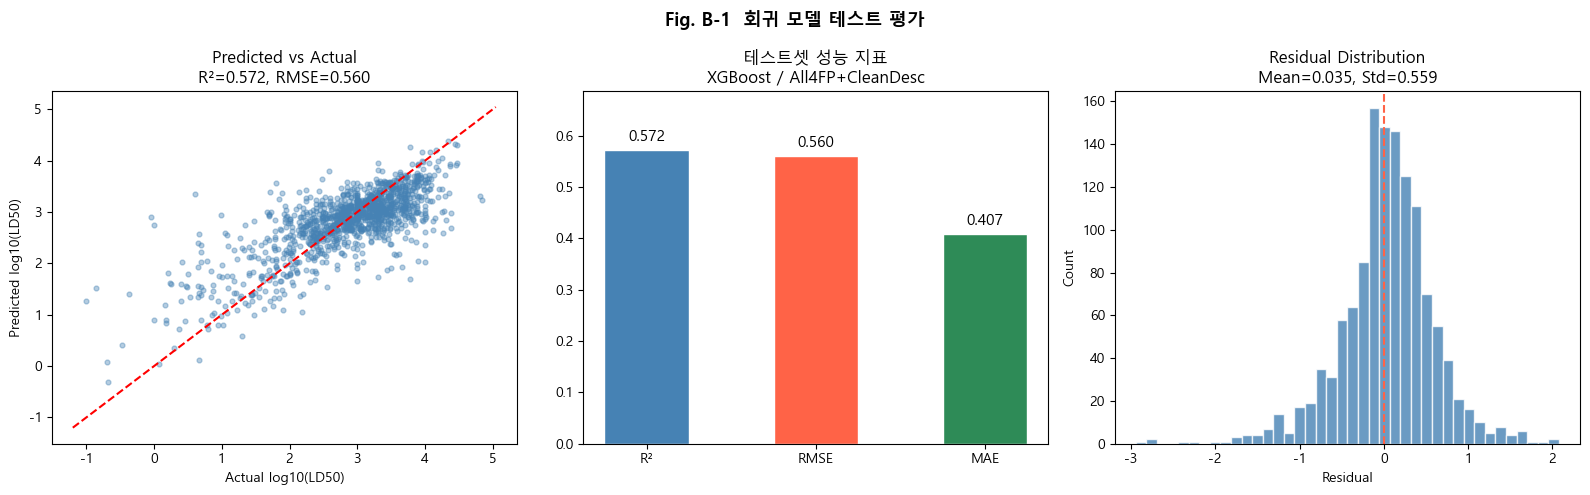

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mn = min(y_reg_test.min(), y_reg_pred.min()) - 0.2
mx = max(y_reg_test.max(), y_reg_pred.max()) + 0.2

# 왼쪽: Predicted vs Actual
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.4, s=12, color='steelblue')
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('Actual log10(LD50)')
axes[0].set_ylabel('Predicted log10(LD50)')
axes[0].set_title(f'Predicted vs Actual\nR²={r2:.3f}, RMSE={rmse:.3f}')

# 가운데: 성능 지표 막대
metrics = {'R²': r2, 'RMSE': rmse, 'MAE': mae}
colors  = ['steelblue', 'tomato', 'seagreen']
axes[1].bar(metrics.keys(), metrics.values(), color=colors, edgecolor='white', width=0.5)
for i, (k, v) in enumerate(metrics.items()):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('테스트셋 성능 지표\nXGBoost / All4FP+CleanDesc')
axes[1].set_ylim(0, max(metrics.values()) * 1.2)

# 오른쪽: 잔차 히스토그램
residuals = y_reg_test - y_reg_pred
axes[2].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='tomato', lw=1.5, ls='--')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nMean={residuals.mean():.3f}, Std={residuals.std():.3f}')

plt.suptitle('Fig. B-1  회귀 모델 테스트 평가', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. 실험 결과 저장 & 최고 모델 저장

**출력 파일**:
- `experiment_results.csv` — 분류 + 회귀 전체 CV 결과
- `experiment_best.csv` — 모델 종류별 최고 성능
- `model_best.joblib` — 최고 분류 모델 (feature pipeline 포함)

In [65]:
import os, joblib

# experiment_results.csv
results_summary = pd.DataFrame([
    {'Task': 'Classification', 'Descriptor': best_dname_clf,
     'Model': best_mname_clf,  'Metric': 'Balanced Accuracy', 'Score': bal_acc},
    {'Task': 'Classification', 'Descriptor': best_dname_clf,
     'Model': best_mname_clf,  'Metric': 'ROC-AUC', 'Score': roc_auc},
    {'Task': 'Regression',     'Descriptor': best_dname_reg,
     'Model': best_mname_reg,  'Metric': 'R²',   'Score': r2},
    {'Task': 'Regression',     'Descriptor': best_dname_reg,
     'Model': best_mname_reg,  'Metric': 'RMSE', 'Score': rmse},
])
results_summary.to_csv('experiment_results.csv', index=False)
print('experiment_results.csv 저장 완료')
print(results_summary.to_string(index=False))


experiment_results.csv 저장 완료
          Task       Descriptor   Model            Metric    Score
Classification       MACCS only     SVM Balanced Accuracy 0.771339
Classification       MACCS only     SVM           ROC-AUC 0.869027
    Regression All4FP+CleanDesc XGBoost                R² 0.572172
    Regression All4FP+CleanDesc XGBoost              RMSE 0.560086


In [69]:
use_ap   = 'AP'   in best_dname_clf
use_tor  = 'Tor'  in best_dname_clf
use_phys = 'Desc' in best_dname_clf

save_dict = {
    'task'              : 'binary_classification',
    'dataset'           : 'NTP ICE Acute Oral',
    'best_descriptor'   : best_dname_clf,
    'best_model_name'   : best_mname_clf,
    'model'             : final_clf,
    'var_selector'      : var_sel,
    'corr_keep_cols'    : keep_cols,
    'use_ap'            : use_ap,
    'use_tor'           : use_tor,
    'use_phys'          : use_phys,
    'optimal_threshold' : 0.5,
    'test_metrics': {
        'balanced_accuracy': bal_acc,
        'roc_auc'          : roc_auc,
        'mcc'              : mcc,
        'f1'               : f1,
    },
}
joblib.dump(save_dict, 'model_best.joblib')
print('model_best.joblib 저장 완료')
print(f'  모델: {best_mname_clf}  /  디스크립터: {best_dname_clf}')

# 회귀 모델도 별도 저장
reg_save = {
    'task'            : 'regression',
    'best_descriptor' : best_dname_reg,
    'best_model_name' : best_mname_reg,
    'model'           : final_reg,
    'var_selector'    : var_sel,
    'corr_keep_cols'  : keep_cols,
}
joblib.dump(reg_save, 'model_best_reg.joblib')
print('model_best_reg.joblib 저장 완료')

model_best.joblib 저장 완료
  모델: SVM  /  디스크립터: MACCS only
model_best_reg.joblib 저장 완료


## 9. 새 분자 예측 예시

저장된 모델을 로드하여 새로운 SMILES를 입력하면 독성을 예측할 수 있습니다.

In [72]:
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors
from rdkit.Chem import rdMolDescriptors

# ── 분류 모델 로드 ──────────────────────────────────────────────────────
clf_loaded    = joblib.load('model_best.joblib')
model_clf     = clf_loaded['model']
var_sel_l     = clf_loaded['var_selector']
keep_cols_l   = clf_loaded['corr_keep_cols']
opt_thr       = clf_loaded['optimal_threshold']
best_desc_clf = clf_loaded['best_descriptor']

# ── 회귀 모델 로드 ──────────────────────────────────────────────────────
reg_loaded    = joblib.load('model_best_reg.joblib')
model_reg     = reg_loaded['model']
best_desc_reg = reg_loaded['best_descriptor']

print(f'분류 모델: {clf_loaded["best_model_name"]} | {best_desc_clf}')
print(f'회귀 모델: {reg_loaded["best_model_name"]} | {best_desc_reg}')

def build_features(mol, best_desc, var_sel=None, keep_cols=None):
    """descriptor 이름 → 피처 벡터"""
    def get_morgan(): return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
    def get_maccs():  return np.array(MACCSkeys.GenMACCSKeys(mol))
    def get_ap():     return np.array(rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=2048))
    def get_tor():    return np.array(rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=2048))
    def get_phys():
        raw = []
        for _, fn in Descriptors.descList:
            try: v = float(fn(mol)); raw.append(v if np.isfinite(v) else 0.0)
            except: raw.append(0.0)
        return var_sel.transform(np.array(raw).reshape(1,-1))[0][keep_cols]

    desc_map = {
        'Morgan only'       : lambda: [get_morgan()],
        'MACCS only'        : lambda: [get_maccs()],
        'AtomPair only'     : lambda: [get_ap()],
        'Torsion only'      : lambda: [get_tor()],
        'RDKit Desc'        : lambda: [get_phys()],
        'Morgan+MACCS'      : lambda: [get_morgan(), get_maccs()],
        'Morgan+MACCS+Desc' : lambda: [get_morgan(), get_maccs(), get_phys()],
        'All4FP (FP only)'  : lambda: [get_morgan(), get_maccs(), get_ap(), get_tor()],
        'All4FP+CleanDesc'  : lambda: [get_morgan(), get_maccs(), get_ap(), get_tor(), get_phys()],
    }

    if best_desc not in desc_map:
        raise ValueError(f'알 수 없는 디스크립터: {best_desc}')

    return np.hstack(desc_map[best_desc]()).reshape(1, -1)

def predict_toxicity(smiles_list):
    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            results.append({'SMILES': smi, 'Label': 'Invalid SMILES'})
            continue

        # 분류 예측
        X_clf = build_features(mol, best_desc_clf, var_sel_l, keep_cols_l)
        proba = model_clf.predict_proba(X_clf)[0, 1]
        pred  = int(proba >= opt_thr)
        label = '독성 (LD50 ≤ 300 mg/kg)' if pred == 1 else '비독성 (LD50 > 300 mg/kg)'

        # 회귀 예측
        X_reg    = build_features(mol, best_desc_reg, var_sel_l, keep_cols_l)
        log_ld50 = float(model_reg.predict(X_reg)[0])
        ld50_val = round(10 ** log_ld50, 1)

        results.append({
            'SMILES'      : smi,
            'Pred_logLD50': round(log_ld50, 3),
            'Pred_LD50'   : f'{ld50_val} mg/kg',
            'Prob_Toxic'  : round(proba, 4),
            'Prediction'  : pred,
            'Label'       : label,
        })
    return pd.DataFrame(results)

# 테스트 분자
# 니코틴: LD50 ~50 mg/kg (독성)
# 에탄올: LD50 ~7,000 mg/kg (비독성)
# 파라콰트(제초제): LD50 ~150 mg/kg (독성)
test_smiles = [
    'CN1CCC[C@H]1c1cccnc1',          # 니코틴 (독성, LD50 ~50 mg/kg)
    'CCO',                             # 에탄올 (비독성, LD50 ~7,000 mg/kg)
    'C[n+]1ccc(-c2cc[n+](C)cc2)cc1',  # 파라콰트 (독성, LD50 ~150 mg/kg)
]
print(predict_toxicity(test_smiles).to_string(index=False))

분류 모델: SVM | MACCS only
회귀 모델: XGBoost | All4FP+CleanDesc
                       SMILES  Pred_logLD50    Pred_LD50  Prob_Toxic  Prediction                  Label
         CN1CCC[C@H]1c1cccnc1         2.053  113.0 mg/kg      0.7419           1  독성 (LD50 ≤ 300 mg/kg)
                          CCO         3.671 4690.2 mg/kg      0.1027           0 비독성 (LD50 > 300 mg/kg)
C[n+]1ccc(-c2cc[n+](C)cc2)cc1         2.099  125.6 mg/kg      0.7420           1  독성 (LD50 ≤ 300 mg/kg)


---

## 10. 결과 요약

### Part A. 이진 분류 모델

| 항목 | 내용 |
|---|---|
| 데이터 | NTP ICE - Acute Oral (LD50, mg/kg) |
| 라벨 기준 | LD50 ≤ 300 mg/kg → Toxic (1) / > 300 mg/kg → Non-toxic (0) |
| 최종 데이터 수 | 6,388개 분자 |
| 최고 조합 | MACCS only + SVM |
| 평가 지표 | Balanced Accuracy, ROC-AUC |
| 평가 방법 | 5-Fold Stratified CV → 테스트셋 최종 평가 |
| 임계값 최적화 | Balanced Accuracy 기준 최적 임계값 탐색 |

### Part B. 회귀 모델

| 항목 | 내용 |
|---|---|
| 목표 변수 | log10(LD50) |
| 최고 조합 | All4FP+CleanDesc + XGBoost |
| 하이퍼파라미터 최적화 | Optuna |
| 평가 지표 | R², RMSE |
| 평가 방법 | 5-Fold CV → Optuna 튜닝 → 테스트셋 최종 평가 |

### 공통

| 항목 | 내용 |
|---|---|
| 디스크립터 | Morgan FP, MACCS Keys, RDKit FP, RDKit Desc (정제 후) |
| 전처리 | 염 제거, 중복 처리, 분산=0 제거, 상관 \|r\|>0.95 제거 |
| 데이터 분할 | Train+Val 80% / Test 20% |

---
## 🎁 가산점 신청 (선택)

| 항목 | 시도 여부 | 관련 셀 |
|---|---|---|
| A. 알고리즘 다양성 (4종) | ✅ | 섹션 5-A, 5-B |
| B. Hyperparameter 탐색 (Optuna) | ✅ | 섹션 6-B |
| C. 모델 성능 평가 (BalAcc, ROC-AUC, R², RMSE) | ✅ | 섹션 7-A, 7-B |
| D. 모델 개발 과정 시각화 & 설명 | ✅ | Fig. A-1, Fig. A-2, Fig. B-1 |